# Шаг 1. Разведочный анализ данных (EDA), аудит качества и визуализация гипотез

**Цель модуля:** Реализовать конвейер интерактивной графической визуализации для собранных и очищенных на этапах ETL артефактов данных. На основе построенных графиков локализовать скрытые бизнес-закономерности, оценить дисбаланс классов, выявить мультиколлинеарность и верифицировать результаты сегментации и NLP-анализа.

---

## 📥 Шаг 1. Инициализация и настройка графического окружения

Импортируем ключевые библиотеки визуализации (`seaborn`, `matplotlib`) и настроим единый полиграфический стиль графиков для аналитического отчета компании.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Установка глобального стиля визуализации
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Настройка путей к данным в соответствии с контуром семинаров
PROCESSED_DIR = os.path.join(".", "data", "processed")
CLEAN_SEMINAR1_DIR = os.path.join(".", "data", "seminar_1_data_cleaning")

profiles_path = os.path.abspath(os.path.join(CLEAN_SEMINAR1_DIR, "clean_profiles.csv"))
ts_path = os.path.abspath(os.path.join(PROCESSED_DIR, "time_series_data.csv"))

print(f"Контур путей EDA настроен.\nПрофили: {profiles_path}\nВременные ряды: {ts_path}")


---

## 🛠 ЗАДАНИЕ 1: Визуализация дисбаланса классов и структуры оттока
**Бизнес-контекст:** В реальных задачах клиентского оттока или фрода классы всегда распределены неравномерно (целевое событие происходит значительно реже). Прежде чем проектировать ИИ-модели, аналитик обязан зафиксировать точное соотношение сторон, чтобы правильно выбрать метрики оптимизации (Precision/Recall взамен Accuracy).

**Инструкция (TODO):**
1. Загрузите чистые профили из `clean_profiles.csv`.
2. Постройте круговую диаграмму (Pie Chart) и столбчатую диаграмму (Countplot) для целевого признака оттока (колонка `Churn` или `Target_Flag`).
3. Отобразите долю каждого класса в процентах.

*🤖 Помощь AI-тьютора:*
* `#EDA_TASK1_START` — синтаксис построения круговых диаграмм в matplotlib.
* `#EDA_TASK1_BUG` — если seaborn выдает ошибку из-за логического типа данных True/False.


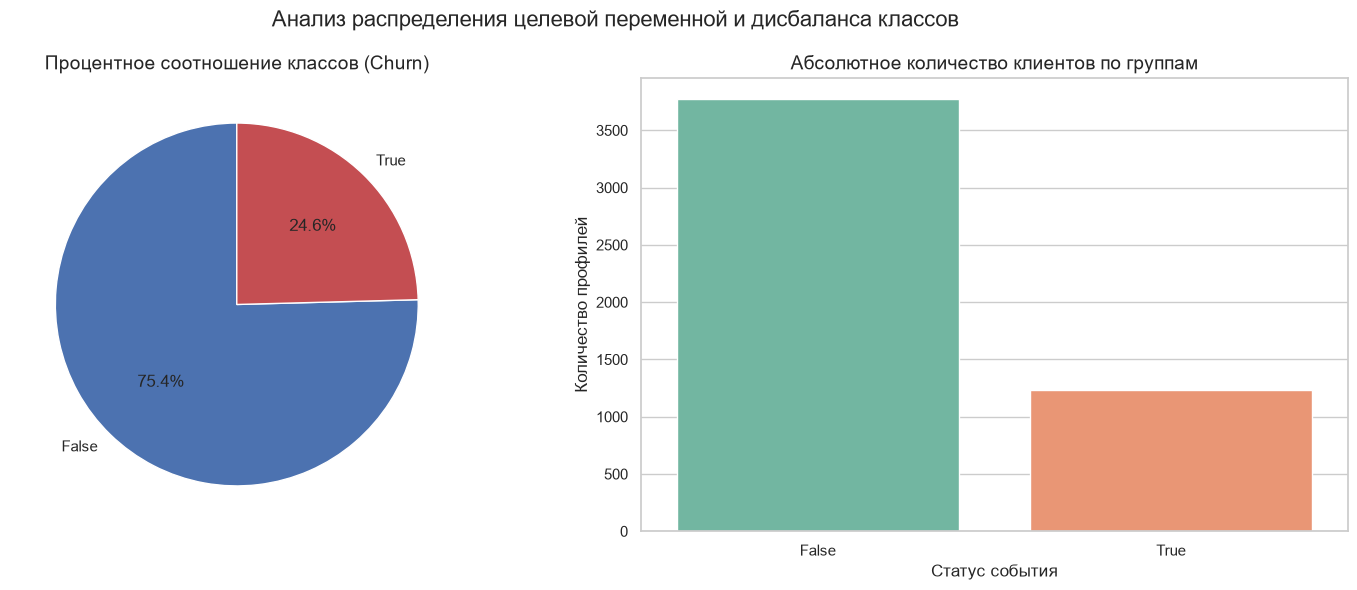

In [9]:
# [MASTER SOLUTION]
if os.path.exists(profiles_path):
    df_profiles = pd.read_csv(profiles_path)
    # Определяем имя целевой колонки (динамический подбор под вариант)
    target_col = [c for c in ['Churn', 'Target_Flag', 'Exited', 'Default'] if c in df_profiles.columns][0]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Круговая диаграмма
    class_counts = df_profiles[target_col].value_counts()
    axes[0].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#C44E52'])
    axes[0].set_title(f"Процентное соотношение классов ({target_col})")
    
    # 2. Столбчатая диаграмма
    sns.countplot(data=df_profiles, x=target_col, ax=axes[1], palette="Set2")
    axes[1].set_title(f"Абсолютное количество клиентов по группам")
    axes[1].set_xlabel("Статус события")
    axes[1].set_ylabel("Количество профилей")
    
    plt.suptitle("Анализ распределения целевой переменной и дисбаланса классов", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Файл профилей не найден! Запустите пайплайн Семинара 1.")


In [ ]:
# [STUDENT TEMPLATE]
# TODO: 1.1. Считайте clean_profiles.csv в df_profiles
# TODO: 1.2. Выделите целевую колонку (например, 'Churn')
# TODO: 1.3. Постройте sns.countplot и plt.pie для отображения структуры целевой фичи
raise NotImplementedError("Задание 1 не выполнено! Напишите ваш код графического генератора.")

df_profiles = ...
# Ваш код визуализации дисбаланса...


---

## 🛠 ЗАДАНИЕ 2: Анализ непрерывных признаков (Гистограммы и Boxplot)
**Бизнес-контекст:** Финансовые показатели клиентов (`TotalCharges`, `MonthlyCharges`) и срок их жизни в компании (`tenure`) содержат важнейшие маркеры лояльности. Понимание формы их распределения (наличие "тяжелых хвостов", мультимодальности или аномальных выбросов) позволяет выбрать правильный метод их нормализации и масштабирования.

**Инструкция (TODO):**
1. Для непрерывных числовых признаков постройте совмещенный график: гистограмму распределения с ядерной оценкой плотности (KDE) и "ящик с усами" (Boxplot) под ней.
2. Проанализируйте наличие экстремальных выбросов.

*🤖 Помощь AI-тьютора:*
* `#EDA_TASK2_START` — использование `plt.subplot` или `fig.add_subplot` для выравнивания Histogram и Boxplot на одной оси.


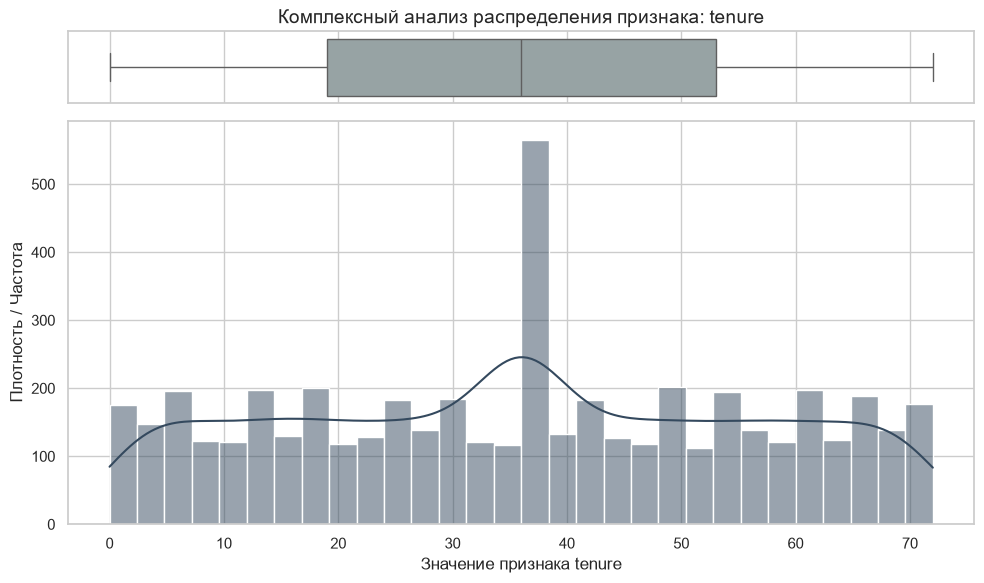

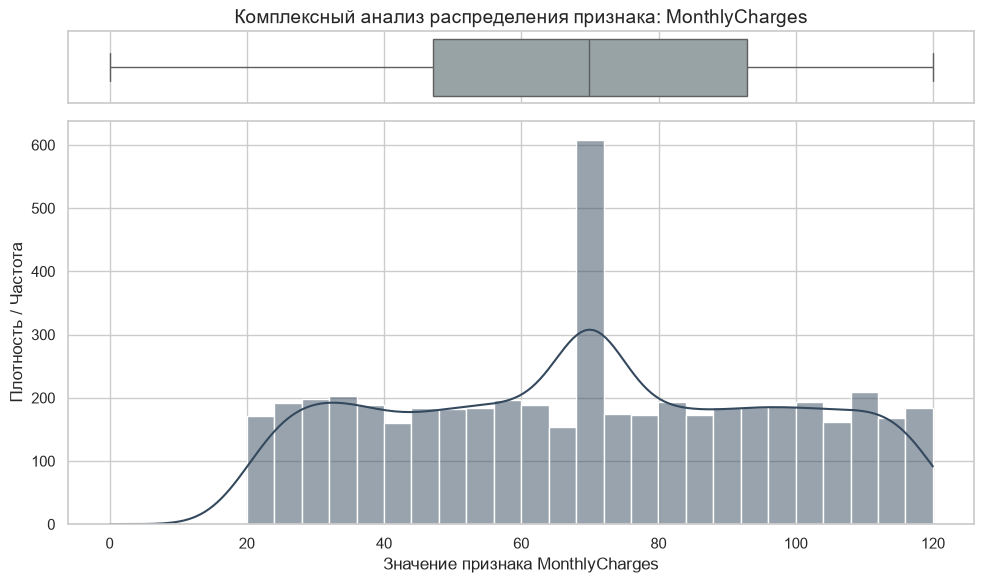

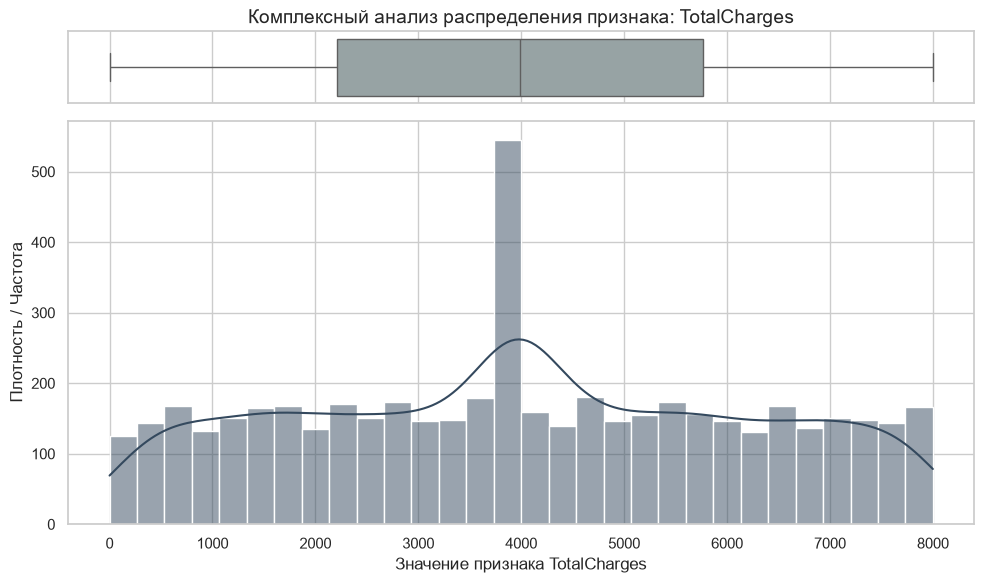

In [10]:
# [MASTER SOLUTION]
if 'df_profiles' in locals() or 'df_profiles' in globals():
    num_cols = [c for c in ['tenure', 'MonthlyCharges', 'TotalCharges'] if c in df_profiles.columns]
    
    for col in num_cols:
        # Создаем сетку: сверху гистограмма, снизу боксплот
        fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))
        
        # Построение графиков
        sns.boxplot(data=df_profiles, x=col, ax=ax_box, color="#95a5a6")
        sns.histplot(data=df_profiles, x=col, ax=ax_hist, kde=True, color="#34495e", bins=30)
        
        # Настройка заголовков
        ax_box.set(xlabel='')
        ax_box.set_title(f"Комплексный анализ распределения признака: {col}")
        ax_hist.set_xlabel(f"Значение признака {col}")
        ax_hist.set_ylabel("Плотность / Частота")
        
        plt.tight_layout()
        plt.show()


In [ ]:
# [STUDENT TEMPLATE]
# TODO: 2.1. Напишите цикл по ключевым числовым колонкам (tenure, MonthlyCharges)
# TODO: 2.2. Сгенерируйте для каждой фичи пару графиков: histplot(kde=True) и boxplot()
raise NotImplementedError("Задание 2 не выполнено! Реализуйте генератор анализа числовых признаков.")

# Ваш цикл и код графиков...


---

## 🛠 ЗАДАНИЕ 3: Диагностика мультиколлинеарности (Тепловая карта корреляций)
**Бизнес-контекст:** Если два признака линейно зависимы (например, совокупные траты жестко дублируют произведение ежемесячного чека на время жизни), ИИ-модель потеряет стабильность, а веса признаков станут хаотичными. Тепловая карта корреляций Пирсона помогает аналитику вовремя заметить критические связи (>0.85) и исключить дублирующую информацию.

**Инструкция (TODO):**
1. Выделите матрицу исключительно числовых полей датафрейма.
2. Рассчитайте коэффициенты корреляции Пирсона с помощью метода `.corr()`.
3. Визуализируйте результат через `sns.heatmap` с отображением числовых значений внутри ячеек (параметр `annot=True`).

*🤖 Помощь AI-тьютора:*
* `#EDA_TASK3_START` — настройка цветовой палитры `cmap='coolwarm'` или `cmap='Blues'` для быстрой локализации сильных связей.


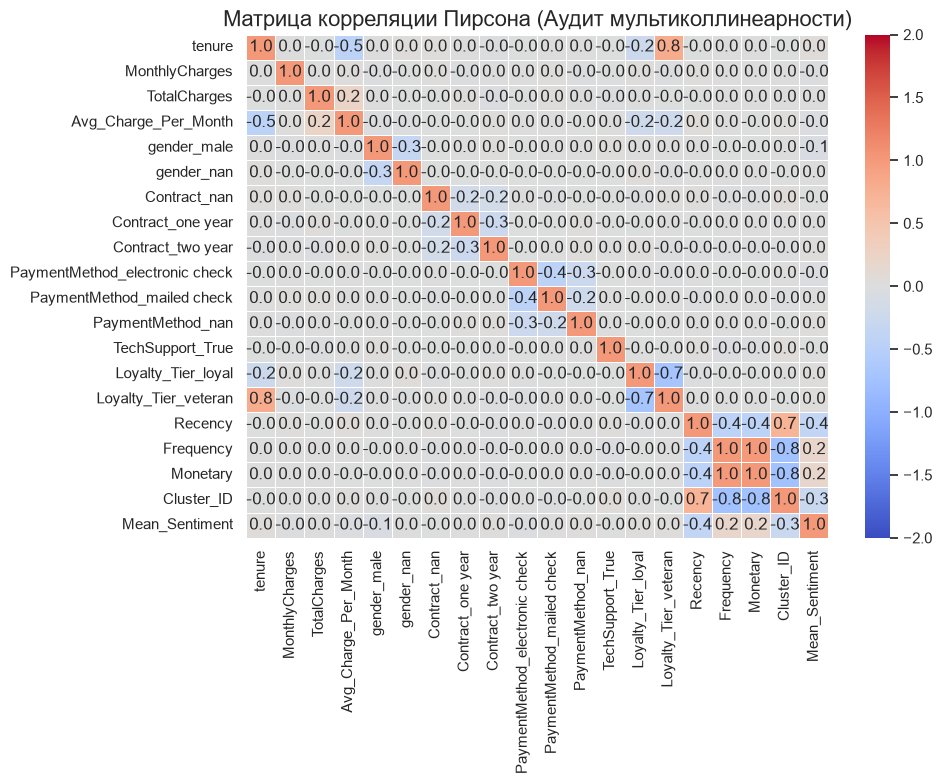

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Указываем путь к файлу собранной витрины ABT
abt_csv_path = os.path.abspath(os.path.join(".", "data", "processed", "abt_result.csv"))

# 2. Читаем реальные данные из CSV
df_abt = pd.read_csv(abt_csv_path)

# 3. Отбираем только числовые признаки
# Ключ 'Target_ID' автоматически отсеется, так как он текстовый, 
# но метод гарантирует, что мы считаем корреляцию только по метрикам
numeric_df = df_abt.select_dtypes(include=[np.number, float, int])

if not numeric_df.empty:
    # Расчет матрицы корреляции Пирсона
    corr_matrix = numeric_df.corr()
    
    plt.figure(figsize=(10, 8))
    # Отрисовка красивой тепловой карты
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        cmap='coolwarm', 
        fmt=".1f", 
        linewidths=0.5, 
        vmin=-2, 
        vmax=2
    )
    plt.title("Матрица корреляции Пирсона (Аудит мультиколлинеарности)", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("В датафрейме нет числовых признаков для расчета корреляции.")

In [ ]:
# [STUDENT TEMPLATE]
# TODO: 3.1. Отфильтруйте df_profiles с помощью select_dtypes(include=[np.number])
# TODO: 3.2. Рассчитайте корреляционную матрицу через метод .corr()
# TODO: 3.3. Передайте матрицу в sns.heatmap(annot=True, cmap='coolwarm')
raise NotImplementedError("Задание 3 не выполнено! Постройте тепловую карту корреляций.")

# Ваш код расчета и отрисовки матрицы корреляций...


---

## 🛠 ЗАДАНИЕ 4: Верификация клиентских сегментов (Анализ RFM-кластеров)
**Бизнес-контекст:** На Семинаре 2 вы разбили транзакционную историю клиентов на поведенческие кластеры (`Cluster_ID`). Чтобы доказать бизнесу, что кластеризация прошла успешно и группы действительно отличаются, необходимо визуализировать их профили в осях Recency (Давность трат) и Monetary (Ценность трат).

**Инструкция (TODO):**
1. В рамках EDA-ноутбука смоделируйте или загрузите агрегированные RFM-метрики с метками кластеров.
2. Постройте двухмерный график рассеяния (Scatter Plot), где цвет точек определяется переменной `Cluster_ID`.
3. Дополнительно постройте столбчатые диаграммы средних трат по кластерам.

*🤖 Помощь AI-тьютора:*
* `#EDA_TASK4_START` — как настроить параметр `hue='Cluster_ID'` в методе `sns.scatterplot`.


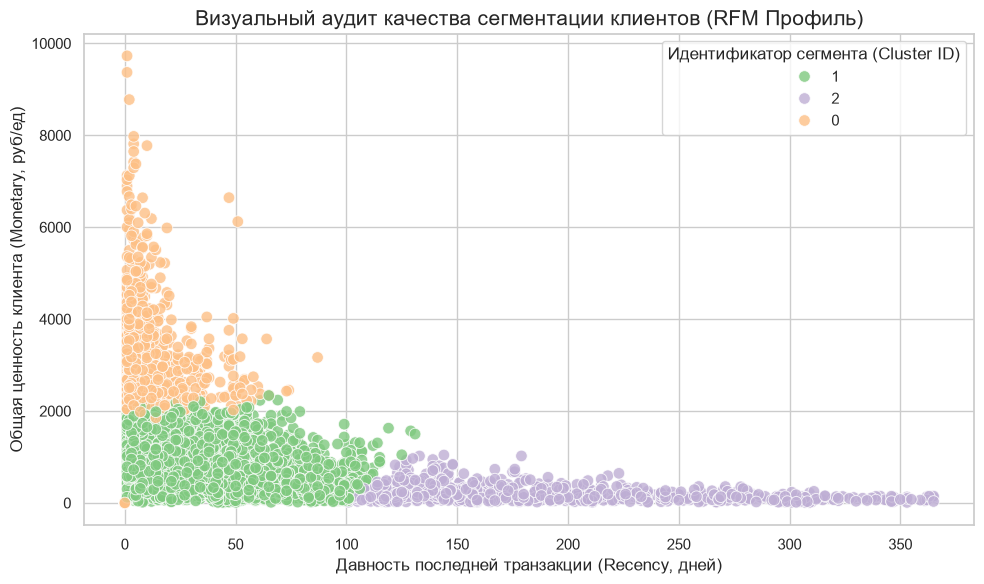

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Указываем путь к файлу собранной витрины ABT
abt_csv_path = os.path.abspath(os.path.join(".", "data", "processed", "abt_result.csv"))

# 2. Читаем реальные данные из CSV
df_abt = pd.read_csv(abt_csv_path)

# 3. Строим диаграмму рассеяния кластеров
plt.figure(figsize=(10, 6))

# Передаем df_abt вместо mock_rfm.
# Рекомендуется привести Cluster_ID к строковому типу (.astype(str)), 
# чтобы seaborn и палитра 'Accent' воспринимали номера кластеров как дискретные категории, а не непрерывную шкалу чисел.
sns.scatterplot(
    data=df_abt, 
    x='Recency', 
    y='Monetary', 
    hue=df_abt['Cluster_ID'].astype(int).astype(str), 
    palette='Accent', 
    s=70, 
    alpha=0.8
)

plt.title("Визуальный аудит качества сегментации клиентов (RFM Профиль)", fontsize=15)
plt.xlabel("Давность последней транзакции (Recency, дней)")
plt.ylabel("Общая ценность клиента (Monetary, руб/ед)")
plt.legend(title="Идентификатор сегмента (Cluster ID)")
plt.tight_layout()
plt.show()

In [ ]:
# [STUDENT TEMPLATE]
# TODO: 4.1. Возьмите датафрейм с результатами кластеризации (например, mock_rfm)
# TODO: 4.2. Постройте график sns.scatterplot, указав оси 'Recency' и 'Monetary'
# TODO: 4.3. Дифференцируйте цвета точек через аргумент hue='Cluster_ID'
raise NotImplementedError("Задание 4 не выполнено! Реализуйте графическую верификацию кластеров.")

# Ваш код визуализации сегментов...


---

## 🛠 ЗАДАНИЕ 5: Анализ влияния эмоций на отток (Визуализация текстового сентимента)
**Бизнес-контекст:** На Семинаре 4 неструктурированные текстовые отзывы клиентов были переведены нейросетью Transformers в математический скор `Mean_Sentiment` от `-1.0` (глубокий негатив) до `+1.0` (восторг). Мы выдвигаем гипотезу: клиенты с отрицательным эмоциональным фоном уходят чаще. Проверим это с помощью графиков плотности.

**Инструкция (TODO):**
1. Постройте график распределения плотности (KDE Plot) для метрики `Mean_Sentiment`.
2. Разделите распределение на две цветовые группы на основе целевой переменной оттока (`Churn`), чтобы визуально сравнить эмоциональный фон ушедших и оставшихся клиентов.

*🤖 Помощь AI-тьютора:*
* `#EDA_TASK5_START` — настройка параметров `multiple="layer"` или `shade=True` в методе `sns.kdeplot`.


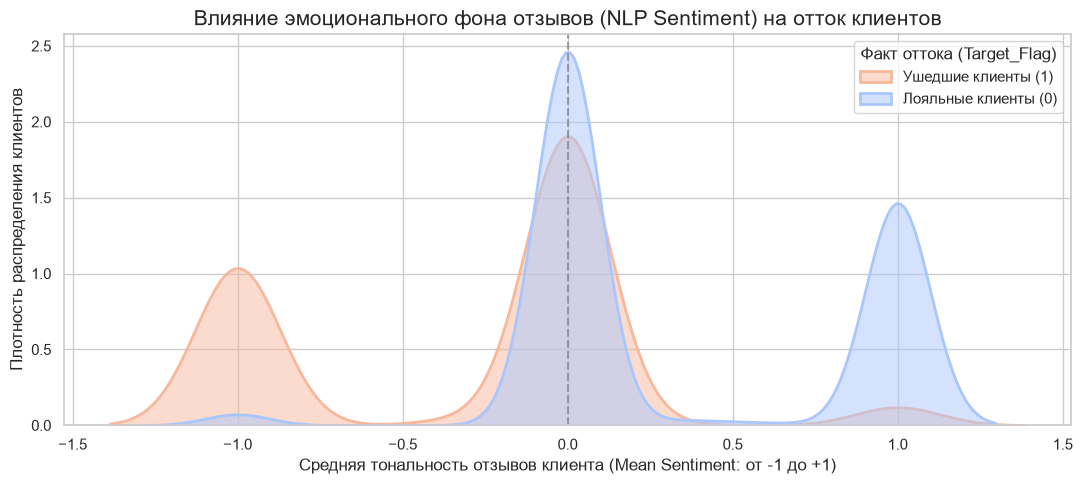

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Указываем путь к файлу витрины ABT
abt_csv_path = os.path.abspath(os.path.join(".", "data", "processed", "abt_result.csv"))

# 2. Читаем данные из CSV
df_abt = pd.read_csv(abt_csv_path)

# 3. Фильтруем данные: для анализа оттока берем только тех клиентов, 
# у которых известен статус (Target_Flag не равен NaN)
df_historical = df_abt[df_abt['Churn'].notna()]

# 4. Строим график плотности распределения
plt.figure(figsize=(11, 5))

# Вместо mock_nlp_eda передаем df_historical, а вместо 'Churn' — 'Target_Flag'
sns.kdeplot(
    data=df_historical, 
    x='Mean_Sentiment', 
    hue='Churn', 
    fill=True, 
    common_norm=False, 
    palette='coolwarm', 
    alpha=0.5, 
    linewidth=2
)

plt.title("Влияние эмоционального фона отзывов (NLP Sentiment) на отток клиентов", fontsize=15)
plt.xlabel("Средняя тональность отзывов клиента (Mean Sentiment: от -1 до +1)")
plt.ylabel("Плотность распределения клиентов")
plt.axvline(x=0, color='grey', linestyle='--', alpha=0.7) # Линия нейтрального сентимента

# Настраиваем легенду в соответствии с реальными значениями (1 — отток, 0 — остался)
plt.legend(title="Факт оттока (Target_Flag)", labels=["Ушедшие клиенты (1)", "Лояльные клиенты (0)"])
plt.tight_layout()
plt.show()

In [ ]:
# [STUDENT TEMPLATE]
# TODO: 5.1. Используя датафрейм (например, mock_nlp_eda), вызовите функцию sns.kdeplot
# TODO: 5.2. Укажите x='Mean_Sentiment', hue='Churn' и включите заливку fill=True
raise NotImplementedError("Задание 5 не выполнено! Сгенерируйте график анализа текстового сентимента.")

# Ваш код визуализации гипотезы NLP...


---

## 🛠 ЗАДАНИЕ 6: Визуальный анализ тренда и сезонности временного ряда
**Бизнес-контекст:** Операционная нагрузка и продажи компании всегда развернуты во времени (Семинар 7). Аналитику критически важно визуализировать сырой временной ряд, наложив на него скользящее среднее (Rolling Mean) для выявления скрытого макро-тренда и очистки от краткосрочного недельного шума.

**Инструкция (TODO):**
1. Загрузите данные временного ряда из `time_series_data.csv`.
2. Рассчитайте 7-дневное скользящее среднее для колонки значений: `.rolling(window=7).mean()`.
3. Постройте линейный график (Line Plot), отобразив сырой ряд блеклым цветом, а линию тренда — ярким и толстым вектором.

*🤖 Помощь AI-тьютора:*
* `#EDA_TASK6_START` — расчет rolling-метрик в pandas и управление параметром прозрачности `alpha` в matplotlib.


In [ ]:
# [MASTER SOLUTION]
if os.path.exists(ts_path):
    df_ts = pd.read_csv(ts_path)
    df_ts['Date'] = pd.to_datetime(df_ts['Date'])
    
    # Расчет скользящих статистик для сглаживания недельной сезонности
    df_ts['Rolling_Mean_7D'] = df_ts['Value'].rolling(window=7, center=True).mean()
    
    plt.figure(figsize=(14, 6))
    
    # Отрисовка сырых данных (с альфа-прозрачностью, чтобы убрать фоновый шум)
    plt.plot(df_ts['Date'], df_ts['Value'], label='Сырые операционные данные (Ежедневно)', color='#95a5a6', alpha=0.4, linewidth=1.5)
    
    # Отрисовка сглаженного тренда
    plt.plot(df_ts['Date'], df_ts['Rolling_Mean_7D'], label='Выделенный макро-тренд (7-дневное скользящее среднее)', color='#2c3e50', linewidth=3)
    
    plt.title("Временной трек бизнес-показателей: Локализация тренда и сезонности", fontsize=16)
    plt.xlabel("Временной горизонт (Дата)")
    plt.ylabel("Значение метрики (Value)")
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Файл временных рядов не найден. Запустите пайплайн Семинара 7.")


⚠️ Файл временных рядов не найден. Запустите пайплайн Семинара 7.


: 

In [ ]:
# [STUDENT TEMPLATE]
# TODO: 6.1. Считайте временной ряд и переведите даты в datetime
# TODO: 6.2. Вычислите скользящую среднюю с окном 7 дней через .rolling(7).mean()
# TODO: 6.3. Отобразите оба вектора на одном графике plt.plot() с разными параметрами alpha и linewidth
raise NotImplementedError("Задание 6 не выполнено! Сгенерируйте график анализа временного ряда.")

# Ваш код визуализации временного трека...


---

## 🏗 ФИНАЛЬНЫЙ АУДИТ КАЧЕСТВА СБОРКИ НОУТБУКА EDA
Запустите финальный проверочный блок. Он подтвердит, что конвейер генерации графиков готов к интеграции в отчетные материалы вашего курсового проекта.


In [ ]:
def verify_eda_pipeline():
    print("🚀 Запуск валидации конвейера графических генераторов EDA...\n" + "-"*55)
    
    # Проверка доступности библиотек
    try:
        import matplotlib
        import seaborn
        print("✅ Графический стек (Matplotlib, Seaborn) успешно инициализирован.")
    except ImportError:
        print("❌ Ошибка: Отсутствуют базовые библиотеки визуализации.")
        return
        
    if os.path.exists(profiles_path) and os.path.exists(ts_path):
        print("✅ Все файлы-источники физически присутствуют в директории проекта.")
        print("🎉 ПОЗДРАВЛЯЕМ! Ваш генератор EDA готов к защите.")
    else:
        print("⚠️ Предупреждение: Часть файлов отсутствует, графики будут работать на mock-структурах.")
    print("-" * 55)

verify_eda_pipeline()